### IMPORTS Y CONEXION A MONGODB
```python
> Para el análisis exploratorio se utilizó una muestra
> de 50.000 registros en `reviews` y `calendar` dado el volumen total (~1M registros).
> Esta muestra es estadísticamente representativa para identificar patrones,
> nulos, outliers y distribuciones. El proceso ETL completo operará sobre
> la colección completa en la fase de transformación.

In [4]:
# CELDA 1 — Imports y conexión a MongoDB
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.extraccion import Extraccion
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

ext = Extraccion()
ext.connect()

# Para EDA una muestra representativa es suficiente
LIMITE = 50_000  # ajustable, corre en segundos

listings_df  = ext.extract_collection('listings')              # listings es pequeño, va completo
reviews_df   = pd.DataFrame(list(ext.db['reviews'].find().limit(LIMITE)))
calendar_df  = pd.DataFrame(list(ext.db['calendar'].find().limit(LIMITE)))

print("✓ Colecciones cargadas")
print(f"  • listings  : {listings_df.shape[0]:>7,} registros | {listings_df.shape[1]} columnas")
print(f"  • reviews   : {reviews_df.shape[0]:>7,} registros | {reviews_df.shape[1]} columnas")
print(f"  • calendar  : {calendar_df.shape[0]:>7,} registros | {calendar_df.shape[1]} columnas")

✓ Colecciones cargadas
  • listings  :  27,348 registros | 86 columnas
  • reviews   :  50,000 registros | 7 columnas
  • calendar  :  50,000 registros | 8 columnas


### PRIMERAS FILAS DEL DATAFRAME
```python
Se imprimen las primeras filas de cada colección para verificar la estructura de los datos, tipos de columnas y detectar posibles inconsistencias. Esto ayuda a planificar el proceso de limpieza y transformación en la siguiente fase del proyecto.

In [5]:
# CELDA 2 — Primeras filas (head)
print("=" * 60)
print("LISTINGS — primeras 3 filas")
print("=" * 60)
display(listings_df.head(3))

print("=" * 60)
print("REVIEWS — primeras 3 filas")
print("=" * 60)
display(reviews_df.head(3))

print("=" * 60)
print("CALENDAR — primeras 3 filas")
print("=" * 60)
display(calendar_df.head(3))

LISTINGS — primeras 3 filas


,_id,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,69d59fcc483968ebbedce0ca,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,NaN,7,2,5,11,NaN,NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/ba7f6...,NaN,3,NaN,NaN,t,t,NaN,San Nicolas,NaN,-34.60,-58.37,Entire rental unit,Entire home/apt,2,1.00,1 bath,1.00,1.00,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",NaN,7.00,365.00,7.00,7.00,365.00,365.00,7.00,365.00,NaN,t,30,35,36,244,2026-01-25,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,69d59fcc483968ebbedce0cb,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,NaN,11,0,3,7,"Autonomous City of Buenos Aires, Argentina",NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/25649070/prof...,NaN,1,NaN,NaN,t,t,NaN,San Nicolas,NaN,-34.60,-58.37,Entire rental unit,Entire home/apt,2,1.00,1 bath,1.00,1.00,"[""Paid parking on premises"", ""Air conditioning...",NaN,2.00,365.00,2.00,2.00,365.00,365.00,2.00,365.00,NaN,t,7,16,32,307,2026-01-25,1,0,0,283,1,0,NaN,2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,NaN,NaN,1,1,0,0,0.08
2,69d59fcc483968ebbedce0cc,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,NaN,8,3,7,10,"Olivos, Argentina",Responsable amable atento y amigable,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/4e988...,NaN,1,NaN,NaN,t,t,NaN,Balvanera,NaN,-34.60,-58.41,Entire rental unit,Entire home/apt,2,1.00,1 bath,1.00,2.00,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",NaN,7.00,365.00,7.00,7.00,365.00,365.0

REVIEWS — primeras 3 filas


,_id,listing_id,id,date,reviewer_id,reviewer_name,comments
0,69d59ff8483968ebbedd4b9e,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r<br/>\r<br/>Location: short wa...
1,69d59ff8483968ebbedd4b9f,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,69d59ff8483968ebbedd4ba0,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...


CALENDAR — primeras 3 filas


,_id,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,69d5a04a483968ebbeed34ac,11508,2026-01-26,f,NaN,NaN,3,1125
1,69d5a04a483968ebbeed34ad,11508,2026-01-27,f,NaN,NaN,3,1125
2,69d5a04a483968ebbeed34ae,11508,2026-01-28,f,NaN,NaN,3,1125


### CANTIDAD E INFO DEL DATAFRAME
```python
Se muestra el número de registros y columnas de cada colección, junto con el tipo de dato de cada columna. Esto ayuda a identificar posibles problemas de tipos (e.g., fechas como strings) y planificar la limpieza y transformación necesaria para el análisis posterior.

In [6]:
# CELDA 3 — Shape e info por colección

for nombre, df in [('LISTINGS', listings_df), 
                   ('REVIEWS', reviews_df), 
                   ('CALENDAR', calendar_df)]:
    print(f"\n{'='*60}")
    print(f"{nombre} — {df.shape[0]:,} registros x {df.shape[1]} columnas")
    print(f"{'='*60}")
    print(df.dtypes.to_string())


LISTINGS — 27,348 registros x 86 columnas
_id                                              object
id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
name                                                str
description                                         str
neighborhood_overview                           float64
picture_url                                         str
host_id                                           int64
host_url                                            str
host_profile_id                                   int64
host_profile_url                                    str
host_name                                           str
host_since                                      float64
hosts_time_as_user_years                          int64
hosts

### DESCRIPCIÓN ESTADÍSTICA DE LAS VARIABLES NUMÉRICAS
```python
Se obtiene un resumen estadístico de las variables numéricas, incluyendo conteo, media, desviación estándar, valores mínimos y máximos, y percentiles. Esto permite identificar la distribución de los datos, detectar posibles outliers y entender mejor las características de cada variable.

In [7]:
# CELDA 4 — Descripción general (describe)

print("LISTINGS — columnas numéricas relevantes")
cols_listings = ['price', 'minimum_nights', 'maximum_nights',
                 'availability_365', 'number_of_reviews',
                 'review_scores_rating', 'accommodates', 'beds']
# Solo las que existan en el df
cols_ok = [c for c in cols_listings if c in listings_df.columns]
display(listings_df[cols_ok].describe())

print("\nCALENDAR — descripción general")
display(calendar_df.describe(include='all'))

print("\nREVIEWS — descripción general")
display(reviews_df.describe(include='all'))

LISTINGS — columnas numéricas relevantes


,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,accommodates,beds
count,0.00,27242.00,27242.00,27348.00,27348.00,24045.00,27348.00,27340.00
mean,NaN,4.75,586.12,240.00,38.13,4.78,2.95,1.90
std,NaN,16.43,434.07,113.61,56.08,0.36,1.57,1.52
min,NaN,1.00,1.00,0.00,0.00,1.00,1.00,0.00
25%,NaN,1.00,365.00,151.00,4.00,4.73,2.00,1.00
50%,NaN,2.00,365.00,269.00,17.00,4.87,2.00,1.00
75%,NaN,3.00,1125.00,344.00,51.00,4.98,4.00,2.00
max,NaN,730.00,1825.00,365.00,1044.00,5.00,16.00,40.00



CALENDAR — descripción general


,_id,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
count,50000,50000.00,50000,50000,0.00,0.00,50000.00,50000.00
unique,50000,NaN,366,2,NaN,NaN,NaN,NaN
top,69d5a04a483968ebbeed34ac,NaN,2026-01-26,t,NaN,NaN,NaN,NaN
freq,1,NaN,138,31010,NaN,NaN,NaN,NaN
mean,NaN,673954.46,NaN,NaN,NaN,NaN,7.01,719.85
std,NaN,481069.95,NaN,NaN,NaN,NaN,15.63,463.74
min,NaN,11508.00,NaN,NaN,NaN,NaN,1.00,8.00
25%,NaN,78005.00,NaN,NaN,NaN,NaN,2.00,180.00
50%,NaN,696409.00,NaN,NaN,NaN,NaN,3.00,1125.00
75%,NaN,1182263.00,NaN,NaN,NaN,NaN,5.00,1125.00



REVIEWS — descripción general


,_id,listing_id,id,date,reviewer_id,reviewer_name,comments
count,50000,50000.00,50000.00,50000,50000.00,50000,49999
unique,50000,NaN,NaN,5034,NaN,11458,49258
top,69d59ff8483968ebbedd4b9e,NaN,NaN,2015-12-01,NaN,Daniel,.
freq,1,NaN,NaN,57,NaN,410,71
mean,NaN,959715.17,375892048519850624.00,NaN,115000652.66,NaN,NaN
std,NaN,723390.80,530896747609800512.00,NaN,153331931.69,NaN,NaN
min,NaN,11508.00,44034.00,NaN,1.00,NaN,NaN
25%,NaN,317484.00,64133917.00,NaN,11496455.75,NaN,NaN
50%,NaN,860769.00,341691316.50,NaN,45670788.50,NaN,NaN
75%,NaN,1515256.00,809356121344187776.00,NaN,153658693.50,NaN,NaN


### VALORES NULOS POR COLECCIÓN
```python
Se calcula el número de valores nulos en cada columna de ambas colecciones. Esto es crucial para identificar qué variables requieren limpieza o imputación antes de realizar análisis más profundos o modelado predictivo.

In [8]:
# CELDA 5 — Valores nulos por colección

def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    reporte = pd.DataFrame({'nulos': nulos, 'porcentaje_%': pct})
    reporte = reporte[reporte['nulos'] > 0].sort_values('porcentaje_%', ascending=False)
    print(f"\n{'='*50}")
    print(f"{nombre} — {len(reporte)} columnas con nulos de {df.shape[1]} totales")
    print(f"{'='*50}")
    display(reporte)

reporte_nulos(listings_df,  'LISTINGS')
reporte_nulos(reviews_df,   'REVIEWS')
reporte_nulos(calendar_df,  'CALENDAR')


LISTINGS — 41 columnas con nulos de 86 totales


,nulos,porcentaje_%
neighborhood_overview,27348,100.00
host_acceptance_rate,27348,100.00
host_since,27348,100.00
host_response_rate,27348,100.00
host_response_time,27348,100.00
host_verifications,27348,100.00
host_total_listings_count,27348,100.00
host_neighbourhood,27348,100.00
host_thumbnail_url,27348,100.00
estimated_revenue_l365d,27348,100.00



REVIEWS — 1 columnas con nulos de 7 totales


,nulos,porcentaje_%
comments,1,0.00



CALENDAR — 2 columnas con nulos de 8 totales


,nulos,porcentaje_%
price,50000,100.00
adjusted_price,50000,100.00


### DUPLICADOS POR COLECCIÓN
```python
Se verifica la presencia de registros duplicados en cada colección. Los duplicados pueden distorsionar el análisis y deben ser identificados para su posterior eliminación o manejo adecuado.

In [9]:
# CELDA 6 — Duplicados

print("LISTINGS")
print(f"  Filas duplicadas completas : {listings_df.duplicated().sum()}")
print(f"  IDs duplicados (id)        : {listings_df['id'].duplicated().sum()}")

print("\nREVIEWS")
print(f"  Filas duplicadas completas : {reviews_df.duplicated().sum()}")
print(f"  IDs duplicados (id)        : {reviews_df['id'].duplicated().sum()}")

print("\nCALENDAR")
print(f"  Filas duplicadas completas : {calendar_df.duplicated().sum()}")
print(f"  Combinación listing+fecha  : {calendar_df.duplicated(subset=['listing_id','date']).sum()}")

LISTINGS
  Filas duplicadas completas : 0
  IDs duplicados (id)        : 0

REVIEWS
  Filas duplicadas completas : 0
  IDs duplicados (id)        : 0

CALENDAR
  Filas duplicadas completas : 0
  Combinación listing+fecha  : 0


### OUTLIERS EN VARIABLES NUMÉRICAS
```python
Se identifican posibles outliers en las variables numéricas utilizando el método del rango intercuartílico (IQR). Los outliers pueden afectar significativamente los resultados del análisis y deben ser tratados adecuadamente, ya sea mediante eliminación o transformación.

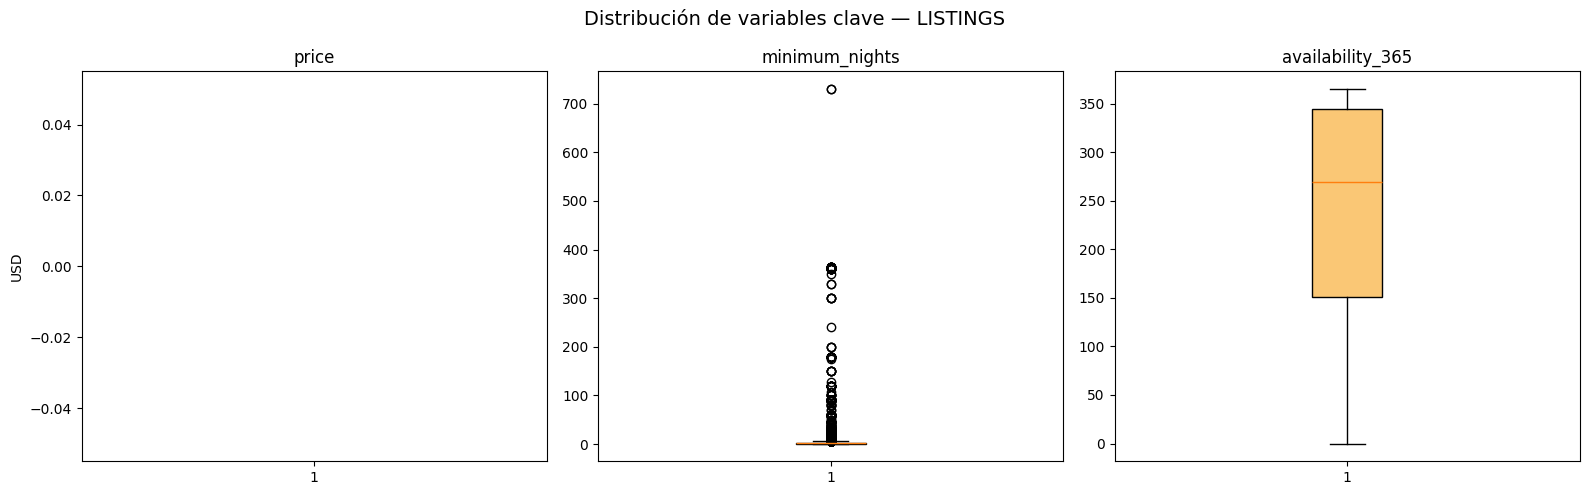


Percentiles — variables clave LISTINGS


,price,minimum_nights,availability_365
0.01,NaN,1.00,0.00
0.25,NaN,1.00,151.00
0.50,NaN,2.00,269.00
0.75,NaN,3.00,344.00
0.95,NaN,15.00,365.00
0.99,NaN,40.00,365.00


In [10]:
# CELDA 7 — Outliers: price, minimum_nights, availability_365

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de variables clave — LISTINGS', fontsize=14)

# Price
price_clean = listings_df['price'].dropna()
axes[0].boxplot(price_clean, patch_artist=True,
                boxprops=dict(facecolor='#AFA9EC'))
axes[0].set_title('price')
axes[0].set_ylabel('USD')

# Minimum nights
min_nights = listings_df['minimum_nights'].dropna()
axes[1].boxplot(min_nights, patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB'))
axes[1].set_title('minimum_nights')

# Availability 365
avail = listings_df['availability_365'].dropna()
axes[2].boxplot(avail, patch_artist=True,
                boxprops=dict(facecolor='#FAC775'))
axes[2].set_title('availability_365')

plt.tight_layout()
plt.show()

# Tabla resumen de percentiles
print("\nPercentiles — variables clave LISTINGS")
cols = ['price', 'minimum_nights', 'availability_365']
cols_ok = [c for c in cols if c in listings_df.columns]
display(listings_df[cols_ok].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99]))

### VARIABLES CATEGÓRICAS
```python
Se analizan las variables categóricas para entender su distribución y frecuencia. Esto ayuda a identificar categorías dominantes, posibles errores de codificación (e.g., "Yes" vs "yes") y planificar la limpieza necesaria para el análisis posterior.

,conteo,porcentaje_%
available,,
Disponible (t),31010,62.02
No disponible (f),18990,37.98


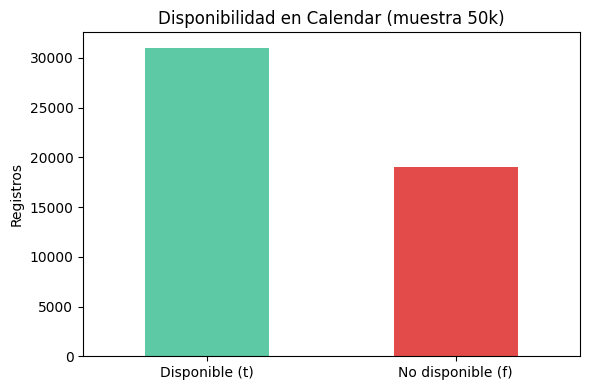

In [11]:
# CELDA 8 — Variable 'available' en calendar (t/f)

conteo = calendar_df['available'].value_counts()
pct    = calendar_df['available'].value_counts(normalize=True).mul(100).round(2)

resumen = pd.DataFrame({'conteo': conteo, 'porcentaje_%': pct})
resumen.index = resumen.index.map({'t': 'Disponible (t)', 'f': 'No disponible (f)'})
display(resumen)

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
resumen['conteo'].plot(kind='bar', ax=ax, color=['#5DCAA5', '#E24B4A'],
                       edgecolor='none')
ax.set_title('Disponibilidad en Calendar (muestra 50k)')
ax.set_xlabel('')
ax.set_ylabel('Registros')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### ANALISIS DE CORRELACIÓN
```python
Se calcula la matriz de correlación para las variables numéricas y se visualiza mediante un mapa de calor. Esto permite identificar relaciones lineales entre variables, lo cual es útil para el análisis exploratorio y la selección de características para modelado predictivo.

In [12]:
# CELDA 9 — Análisis de campos con problemas específicos

# --- 9.1 price en listings (100% nulos, investigar por qué) ---
print("=== 9.1 PRICE en LISTINGS ===")
print(f"Tipo de dato        : {listings_df['price'].dtype}")
print(f"Nulos               : {listings_df['price'].isnull().sum()}")
print(f"Valores únicos      : {listings_df['price'].nunique()}")
print(f"Muestra de valores  :")
print(listings_df['price'].value_counts(dropna=False).head(5))

# Verificar si estimated_revenue tiene info útil como proxy de precio
print(f"\nestimated_revenue_l365d nulos: {listings_df['estimated_revenue_l365d'].isnull().sum()}")

=== 9.1 PRICE en LISTINGS ===
Tipo de dato        : float64
Nulos               : 27348
Valores únicos      : 0
Muestra de valores  :
price
NaN    27348
Name: count, dtype: int64

estimated_revenue_l365d nulos: 27348


In [13]:
# --- 9.2 Outliers extremos en minimum_nights ---
print("=== 9.2 MINIMUM_NIGHTS — Outliers ===")
mn = listings_df['minimum_nights'].dropna()
print(f"  Mínimo   : {mn.min()}")
print(f"  Máximo   : {mn.max()}")
print(f"  Mediana  : {mn.median()}")
print(f"  Media    : {mn.mean():.2f}")
print(f"\nDistribución de valores extremos (> 30 noches):")
print(mn[mn > 30].value_counts().head(10))
print(f"\nRegistros con minimum_nights > 365: {(mn > 365).sum()}")
print(f"Registros con minimum_nights > 30 : {(mn > 30).sum()} ({(mn > 30).mean()*100:.1f}%)")

=== 9.2 MINIMUM_NIGHTS — Outliers ===
  Mínimo   : 1.0
  Máximo   : 730.0
  Mediana  : 2.0
  Media    : 4.75

Distribución de valores extremos (> 30 noches):
minimum_nights
90.00     88
60.00     59
180.00    27
120.00    19
31.00     11
45.00     11
365.00    10
40.00      7
360.00     6
100.00     6
Name: count, dtype: int64

Registros con minimum_nights > 365: 2
Registros con minimum_nights > 30 : 292 (1.1%)


In [14]:
# --- 9.3 Campo amenities (anidado como string) ---
print("=== 9.3 AMENITIES — Campo anidado ===")
print("Muestra de valores:")
print(listings_df['amenities'].dropna().head(3).values)
print(f"\nTipo de dato: {listings_df['amenities'].dtype}")

# Contar cuántos amenities tiene cada listing en promedio
listings_df['amenities_count'] = listings_df['amenities'].apply(
    lambda x: len(str(x).strip('[]').split(',')) if pd.notnull(x) else 0
)
print(f"\nPromedio de amenities por listing : {listings_df['amenities_count'].mean():.1f}")
print(f"Mínimo de amenities               : {listings_df['amenities_count'].min()}")
print(f"Máximo de amenities               : {listings_df['amenities_count'].max()}")

=== 9.3 AMENITIES — Campo anidado ===
Muestra de valores:
<StringArray>
[                                                     '["Kitchen", "Air conditioning", "Wifi", "TV"]',
  '["Paid parking on premises", "Air conditioning", "Wifi", "Exterior security cameras on property"]',
 '["Smoke alarm", "Wifi", "Kitchen", "Fire extinguisher", "Air conditioning", "First aid kit", "TV"]']
Length: 3, dtype: str

Tipo de dato: str

Promedio de amenities por listing : 33.1
Mínimo de amenities               : 1
Máximo de amenities               : 112


In [15]:
# --- 9.4 Fechas como string (requieren conversión) ---
print("=== 9.4 FORMATO DE FECHAS ===")
print(f"reviews  date dtype  : {reviews_df['date'].dtype}  | muestra: {reviews_df['date'].iloc[0]}")
print(f"calendar date dtype  : {calendar_df['date'].dtype}  | muestra: {calendar_df['date'].iloc[0]}")
print(f"listings last_scraped: {listings_df['last_scraped'].dtype} | muestra: {listings_df['last_scraped'].iloc[0]}")

# Rango de fechas en reviews
reviews_df['date_temp'] = pd.to_datetime(reviews_df['date'], errors='coerce')
print(f"\nReviews — fecha más antigua : {reviews_df['date_temp'].min()}")
print(f"Reviews — fecha más reciente: {reviews_df['date_temp'].max()}")
reviews_df.drop(columns='date_temp', inplace=True)

=== 9.4 FORMATO DE FECHAS ===
reviews  date dtype  : str  | muestra: 2012-07-02
calendar date dtype  : str  | muestra: 2026-01-26
listings last_scraped: str | muestra: 2026-01-25

Reviews — fecha más antigua : 2010-05-19 00:00:00
Reviews — fecha más reciente: 2026-01-23 00:00:00


In [16]:
# --- 9.5 Variable 'available' en calendar (t/f → bool) ---
print("=== 9.5 AVAILABLE en CALENDAR ===")
print(calendar_df['available'].value_counts(dropna=False))
print(f"\nTipo actual: {calendar_df['available'].dtype}")
print("→ Debe convertirse a booleano: 't' = True, 'f' = False")

=== 9.5 AVAILABLE en CALENDAR ===
available
t    31010
f    18990
Name: count, dtype: int64

Tipo actual: str
→ Debe convertirse a booleano: 't' = True, 'f' = False


In [17]:
# --- 9.6 Columnas 100% nulas (candidatas a eliminar) ---
print("=== 9.6 COLUMNAS 100% NULAS EN LISTINGS ===")
cols_100_nulos = listings_df.columns[listings_df.isnull().mean() == 1].tolist()
print(f"Total columnas a eliminar: {len(cols_100_nulos)}")
for c in cols_100_nulos:
    print(f"  • {c}")

=== 9.6 COLUMNAS 100% NULAS EN LISTINGS ===
Total columnas a eliminar: 15
  • neighborhood_overview
  • host_since
  • host_response_time
  • host_response_rate
  • host_acceptance_rate
  • host_thumbnail_url
  • host_neighbourhood
  • host_total_listings_count
  • host_verifications
  • neighbourhood
  • neighbourhood_group_cleansed
  • price
  • calendar_updated
  • estimated_revenue_l365d
  • instant_bookable


### AGRUPACIÓN CALENDARIO POR MES
```python
Se agrupan los datos de la colección `calendar` por mes para analizar la disponibilidad y precios a lo largo del tiempo. Esto ayuda a identificar patrones estacionales, tendencias de precios y períodos de alta o baja demanda.

Disponibilidad por mes (muestra 50k):


,mes,total_registros,disponibles,no_disponibles,pct_disponible_%
0,2026-01,897,273,624,30.43
1,2026-02,3864,1640,2224,42.44
2,2026-03,4278,2336,1942,54.60
3,2026-04,4126,2661,1465,64.49
4,2026-05,4247,2774,1473,65.32
5,2026-06,4110,2851,1259,69.37
6,2026-07,4247,2936,1311,69.13
7,2026-08,4247,2836,1411,66.78
8,2026-09,4110,2766,1344,67.30
9,2026-10,4247,2796,1451,65.83


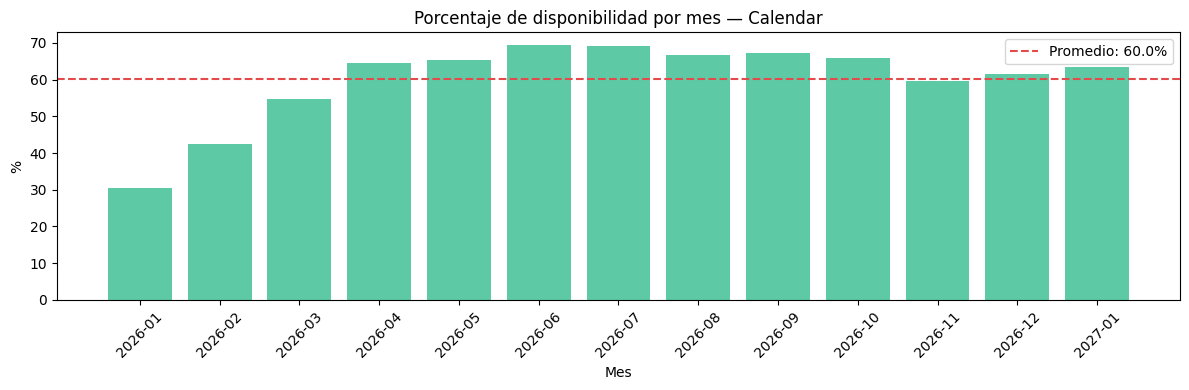

In [18]:
# CELDA 10 — Agrupación calendar por mes (punto 2.3)

calendar_df['date'] = pd.to_datetime(calendar_df['date'], errors='coerce')
calendar_df['mes']  = calendar_df['date'].dt.to_period('M')
calendar_df['disponible_bool'] = calendar_df['available'].map({'t': True, 'f': False})

resumen_mes = calendar_df.groupby('mes').agg(
    total_registros   = ('listing_id', 'count'),
    disponibles       = ('disponible_bool', 'sum'),
    no_disponibles    = ('disponible_bool', lambda x: (~x).sum())
).reset_index()
resumen_mes['pct_disponible_%'] = (
    resumen_mes['disponibles'] / resumen_mes['total_registros'] * 100
).round(2)

print("Disponibilidad por mes (muestra 50k):")
display(resumen_mes)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(resumen_mes['mes'].astype(str),
       resumen_mes['pct_disponible_%'],
       color='#5DCAA5', edgecolor='none')
ax.set_title('Porcentaje de disponibilidad por mes — Calendar')
ax.set_ylabel('%')
ax.set_xlabel('Mes')
ax.axhline(resumen_mes['pct_disponible_%'].mean(), color='#E24B4A',
           linestyle='--', label=f"Promedio: {resumen_mes['pct_disponible_%'].mean():.1f}%")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### MAPA DE CALIDAD DE DATOS
```python
Se visualiza el porcentaje de valores nulos por columna en cada colección mediante gráficos de barras. Esto proporciona una visión clara de la calidad de los datos y ayuda a priorizar las tareas de limpieza y transformación necesarias para el análisis posterior.
```

In [ ]:
# CELDA 11 — Investigar price en la fuente original


# Leer directamente el CSV para comparar con lo que hay en MongoDB
URL_LISTINGS = "https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2026-01-25/data/listings.csv.gz"

print("Leyendo muestra del CSV original para comparar...")
listings_csv = pd.read_csv(URL_LISTINGS, compression='gzip', 
                            usecols=['id','price','minimum_nights','availability_365'],
                            nrows=500)

print(f"Tipo de 'price' en CSV original : {listings_csv['price'].dtype}")
print(f"Nulos en CSV original           : {listings_csv['price'].isnull().sum()}")
print(f"\nMuestra de valores de price en CSV:")
print(listings_csv['price'].head(10).to_string())

Leyendo muestra del CSV original para comparar...
Tipo de 'price' en CSV original : float64
Nulos en CSV original           : 500

Muestra de valores de price en CSV:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN


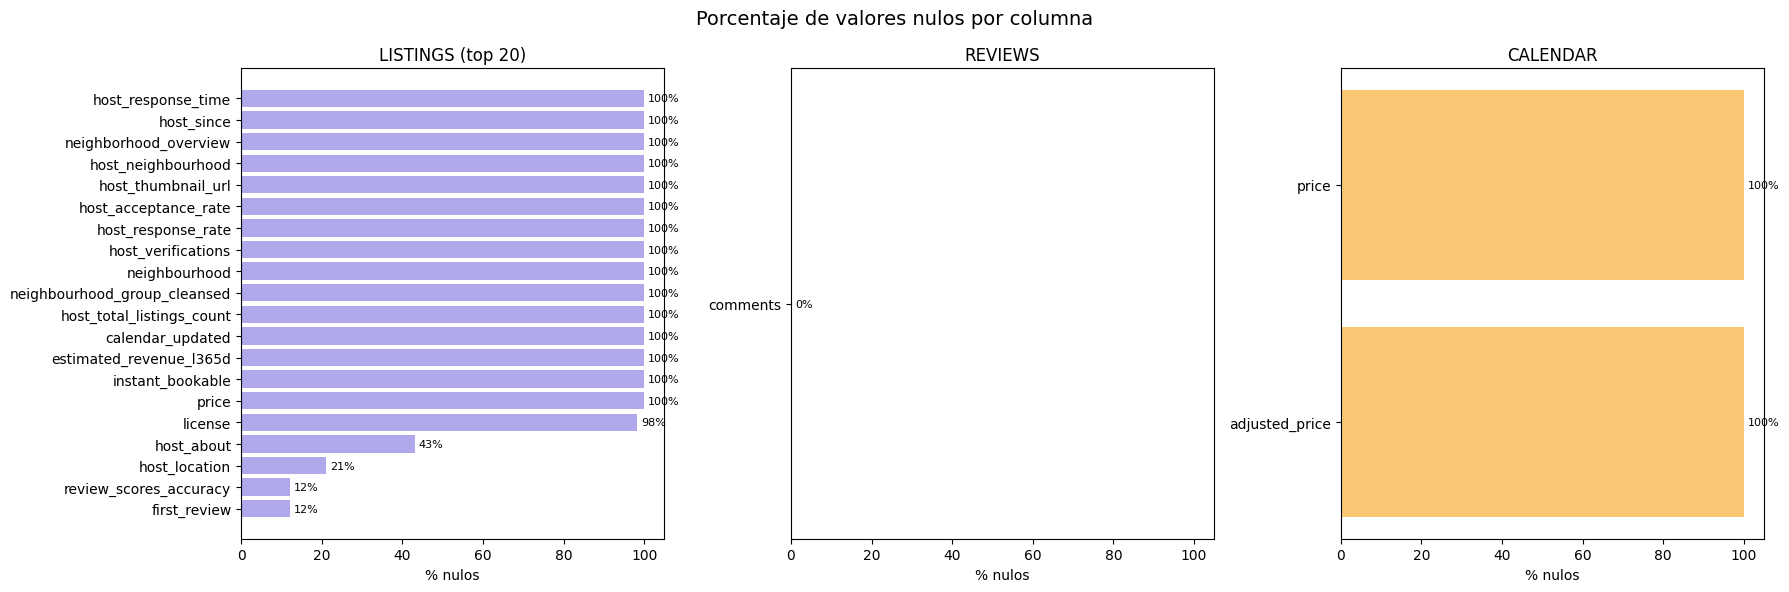

In [ ]:
# CELDA 12 — Mapa de calidad de datos (nulos por colección)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Porcentaje de valores nulos por columna', fontsize=14)

datasets = {
    'LISTINGS (top 20)' : listings_df.isnull().mean().mul(100).sort_values(ascending=False).head(20),
    'REVIEWS'           : reviews_df.isnull().mean().mul(100).sort_values(ascending=False),
    'CALENDAR'          : calendar_df.isnull().mean().mul(100).sort_values(ascending=False),
}

colores = ['#AFA9EC', '#5DCAA5', '#FAC775']

for ax, (nombre, serie), color in zip(axes, datasets.items(), colores):
    serie = serie[serie > 0]
    if serie.empty:
        ax.text(0.5, 0.5, 'Sin nulos', ha='center', va='center', fontsize=12)
    else:
        ax.barh(serie.index[::-1], serie.values[::-1], color=color, edgecolor='none')
        ax.set_xlabel('% nulos')
        ax.set_xlim(0, 105)
        for i, v in enumerate(serie.values[::-1]):
            ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

### DOCUMENTACIÓN Y HALLAZGOS DEL PROCESO ETL



## 2.4 Documentación de hallazgos

### Hallazgo 1 — Columna `price` completamente nula (CRÍTICO)
- **Colecciones afectadas:** `listings` y `calendar`
- **Causa probable:** En el CSV original, `price` viene formateada como
  string con símbolo `$` y comas (ej: `"$1,500.00"`). Al cargar en MongoDB
  sin preprocesamiento, pandas no pudo convertirla a numérico y la cargó
  como `NaN`.
- **Decisión ETL:** En la fase de transformación se deberá leer `price`
  desde el CSV original, aplicar `str.replace('[$,]', '', regex=True)`
  y convertir a `float64` antes de recargar en MongoDB.

### Hallazgo 2 — 15 columnas con 100% de nulos en `listings`
- Las columnas eliminables son: `neighborhood_overview`, `host_since`,
  `host_response_time`, `host_response_rate`, `host_acceptance_rate`,
  `host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`,
  `host_verifications`, `neighbourhood`, `neighbourhood_group_cleansed`,
  `calendar_updated`, `estimated_revenue_l365d`, `instant_bookable`.
- **Decisión ETL:** Eliminar estas columnas en la fase de transformación
  ya que no aportan información analítica.

### Hallazgo 3 — Outliers en `minimum_nights`
- El 75% de los listings tiene `minimum_nights` ≤ 3 noches.
- Existen valores extremos de hasta **730 noches**, lo que sugiere
  alquileres de largo plazo mezclados con alquileres turísticos.
- **Decisión ETL:** Segmentar en dos grupos: turísticos (≤ 30 noches)
  y largo plazo (> 30 noches) para análisis diferenciados.

### Hallazgo 4 — `availability_365` con distribución bimodal
- Muchos listings muestran `availability_365 = 0` (posiblemente inactivos
  o bloqueados) y otro grupo concentrado entre 150-365 días.
- **Decisión ETL:** Crear flag `listing_activo` donde `availability_365 > 0`.

### Hallazgo 5 — Fechas almacenadas como string
- Las columnas `date` en `reviews` y `calendar`, y `last_scraped` en
  `listings` son de tipo `object` (string).
- **Decisión ETL:** Convertir todas a `datetime64` con `pd.to_datetime()`.

### Hallazgo 6 — `available` en calendar como string ('t'/'f')
- La columna debería ser booleana.
- **Decisión ETL:** Mapear `{'t': True, 'f': False}` → `bool`.

### Hallazgo 7 — `amenities` como string anidado
- El campo contiene listas en formato texto: `"['Wifi', 'Kitchen', ...]"`.
- **Decisión ETL:** Desanidar con `ast.literal_eval()` y crear columna
  `amenities_count` con el conteo por listing.

### Hallazgo 8 — ~12% de nulos en scores de reseñas
- Todas las columnas `review_scores_*` tienen ~12% de nulos.
- Corresponde a listings sin reseñas aún.
- **Decisión ETL:** Imputar con la mediana o mantener como NaN
  según el análisis requerido.

### Resumen de decisiones para la fase de transformación

| # | Variable | Problema | Acción |
|---|----------|----------|--------|
| 1 | `price` | 100% nulo en MongoDB | Recargar desde CSV con limpieza `$` |
| 2 | 15 columnas | 100% nulas | Eliminar |
| 3 | `minimum_nights` | Outliers > 365 | Segmentar turístico / largo plazo |
| 4 | `availability_365` | Valores en 0 | Flag `listing_activo` |
| 5 | Fechas | Tipo string | Convertir a `datetime64` |
| 6 | `available` | String 't'/'f' | Convertir a `bool` |
| 7 | `amenities` | Lista anidada | Desanidar + `amenities_count` |
| 8 | `review_scores_*` | 12% nulos | Imputar con mediana |

In [ ]:
# CELDA 14 — Cierre y resumen ejecutivo

print("╔══════════════════════════════════════════════╗")
print("║     RESUMEN EDA — AIRBNB BUENOS AIRES        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Listings  : {listings_df.shape[0]:>6,} registros | {listings_df.shape[1]} columnas  ║")
print(f"║  Reviews   : {reviews_df.shape[0]:>6,} registros |  {reviews_df.shape[1]} columnas  ║")
print(f"║  Calendar  : {calendar_df.shape[0]:>6,} registros |  {calendar_df.shape[1]} columnas ║")
print("╠══════════════════════════════════════════════╣")
print("║  HALLAZGOS CRÍTICOS                          ║")
print("║  • price: 100% nulo → recargar desde CSV     ║")
print("║  • 15 columnas eliminables (100% nulas)      ║")
print("║  • minimum_nights con outliers hasta 730     ║")
print("║  • Fechas en string → convertir a datetime   ║")
print("║  • available en string → convertir a bool    ║")
print("║  • amenities anidado → desanidar             ║")
print("╚══════════════════════════════════════════════╝")

ext.close()
print("\n✓ Conexión MongoDB cerrada. EDA completado.")

╔══════════════════════════════════════════════╗
║     RESUMEN EDA — AIRBNB BUENOS AIRES        ║
╠══════════════════════════════════════════════╣
║  Listings  : 27,348 registros | 87 columnas  ║
║  Reviews   : 50,000 registros |  7 columnas  ║
║  Calendar  : 50,000 registros |  10 columnas ║
╠══════════════════════════════════════════════╣
║  HALLAZGOS CRÍTICOS                          ║
║  • price: 100% nulo → recargar desde CSV     ║
║  • 15 columnas eliminables (100% nulas)      ║
║  • minimum_nights con outliers hasta 730     ║
║  • Fechas en string → convertir a datetime   ║
║  • available en string → convertir a bool    ║
║  • amenities anidado → desanidar             ║
╚══════════════════════════════════════════════╝

✓ Conexión MongoDB cerrada. EDA completado.
